### [주제 : Bream과 Smelt 분류 모델]
- 특성/피처 : H, W, L
- 타겟/라벨 : Species => Bream, Smelt
- 학습 종류 : 지도학습 - 분류
- 학습 방법 : KNN - 최근접이웃 : 유유상종

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier

In [3]:
DATA_FILE ='../Data/Numbers/fish.csv'

In [4]:
# Brem, Smelt
fish_df = pd.read_csv(DATA_FILE, usecols=['Species','Weight','Height','Length'],
                      skiprows=range(36,146))

In [5]:
fish_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  49 non-null     str    
 1   Weight   49 non-null     float64
 2   Length   49 non-null     float64
 3   Height   49 non-null     float64
dtypes: float64(3), str(1)
memory usage: 1.7 KB


**[2] 피쳐로 타겟 분류 가능여부체크**
- 시각회

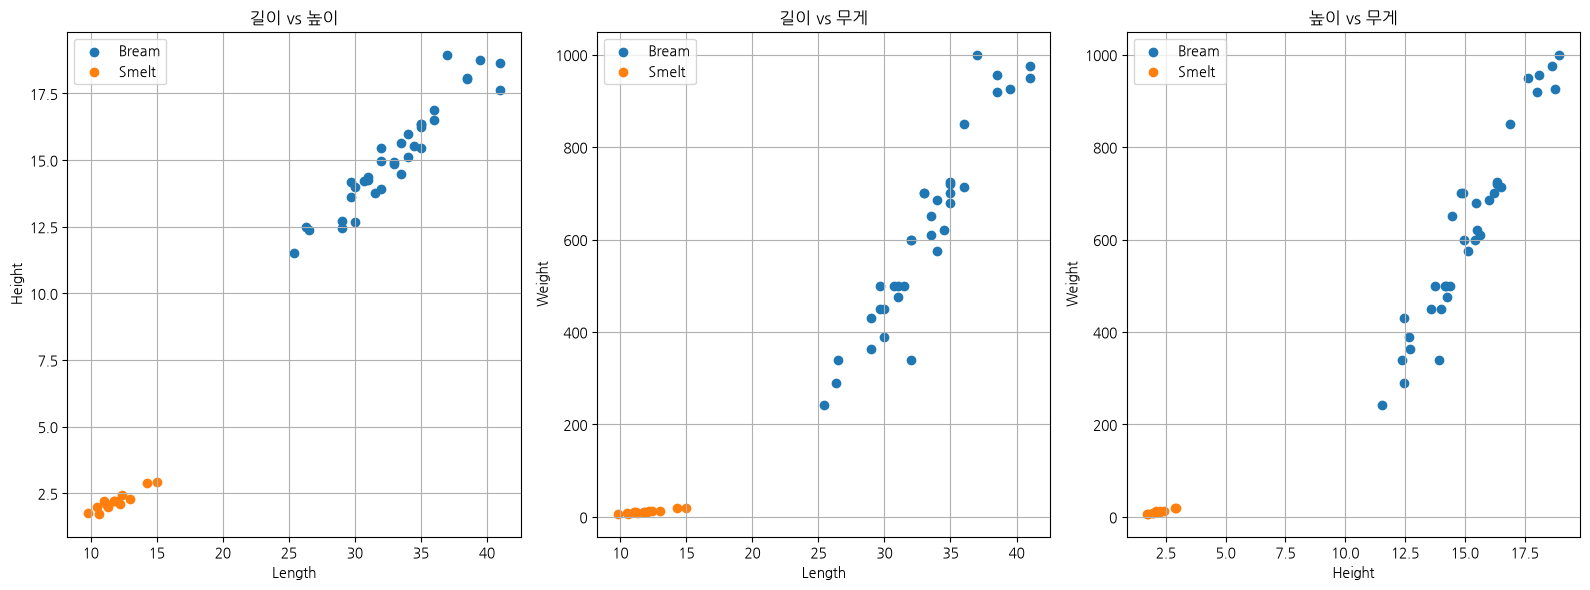

In [6]:
# 길이, 높이 => 2개 품종 식별 체크 | 길이, 무게 => 2개 품종 식별 체크 / 높이, 무게 => 2개 품종 식별 체크
# - 1행 3열, 품종별 다른 색상, 산점도
_, axes = plt.subplots(1, 3, figsize=(16, 6))

plots = [
    ('Length', 'Height', '길이 vs 높이'),
    ('Length', 'Weight', '길이 vs 무게'),
    ('Height', 'Weight', '높이 vs 무게'),
]

for ax, (x_col, y_col, title) in zip(axes, plots):
    for species, group in fish_df.groupby('Species'):
        ax.scatter(group[x_col], group[y_col], label=species)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(title)
    ax.legend()
    ax.grid(True)
plt.tight_layout()
plt.show()

[3] 데이터셋 준비
- 피쳐와 타겟 분리
- 학습용과 테스트용 분리

In [7]:
# => 피쳐와 타겟 분리
feature = fish_df[fish_df.columns[1:]]
target = fish_df[fish_df.columns[0]]

In [8]:
# 학습용, 테스트용 분리 : 분류 모델로 클래스/타겟 비율 유지
x_train, x_test, y_train, y_test = train_test_split(feature,
                                                    target,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=target)

In [9]:
print(x_train.shape, y_train.shape)
print(y_train.value_counts(),'\n', y_train.shape[0],'\n')

print(x_test.shape, y_test.shape)
print(y_test.value_counts(),'\n', y_test.shape[0],'\n')

(39, 3) (39,)
Species
Bream    28
Smelt    11
Name: count, dtype: int64 
 39 

(10, 3) (10,)
Species
Bream    7
Smelt    3
Name: count, dtype: int64 
 10 



**[4] 학습**

In [10]:
prams = {'n_neighbors' : range(1,30,2)}

gs_model = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=prams,
    return_train_score=True,
    n_jobs=-1)

gs_model.fit(x_train,y_train)

res = pd.DataFrame(gs_model.cv_results_)[['param_n_neighbors', 'mean_train_score', 'mean_test_score',
                                          'rank_test_score', 'std_test_score', 'std_test_score']]
gs_best = gs_model.best_estimator_

In [11]:
print(f"best score: {gs_model.best_score_:.4f}")
print(f"best params: {gs_model.best_params_}")

best score: 1.0000
best params: {'n_neighbors': 1}


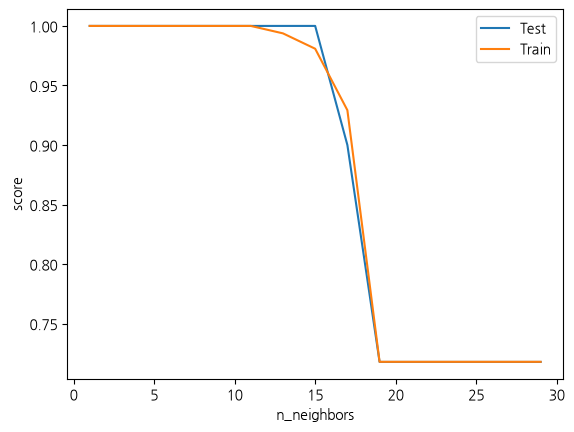

In [12]:
sorted = res.sort_values(by=['param_n_neighbors'])

plt.plot(sorted['param_n_neighbors'], sorted['mean_test_score'], label='Test')
plt.plot(sorted['param_n_neighbors'], sorted['mean_train_score'], label='Train')
plt.xlabel('n_neighbors')
plt.ylabel('score')
plt.legend()
plt.show()

In [14]:
y_pre = gs_best.predict(x_test)

compare = pd.DataFrame(np.vstack([y_test, y_pre]), index=['정답', '예측']).T
compare['결과'] = compare['정답'] == compare['예측']

correct, incorrect = compare['결과'].sum(), compare.shape[0] - compare['결과'].sum()
print(correct, incorrect)

10 0
